# Interaktive Analyse & Metriken-Explorer

Dieses Notebook importiert die modularisierten Analyse- und Vergleichswerkzeuge aus dem `utils_notebook`-Ordner und führt sie nacheinander aus.

## Phase 0

In [1]:
import sys
import os

# Pfad anpassen, um utils_notebook und das eval-Modul zu importieren
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

# Alle modularisierten Funktionen importieren
from utils_notebook.compare import compare_wunden_interactive
from utils_notebook.category_compare import compare_categories_interactive
from utils_notebook.wundbild import zeige_wundbild_interactive
from utils_notebook.metrics_explorer import calculate_scores, display_scores_interactive, calculate_summary, display_summary
from utils_notebook.plot_compare import plot_gt_comparison

# Pfade definieren (Start mit rohem GT)
CSV_PATH = "../data/ground_truth/allgemeine_verbandsklassen.csv"
JSON_DIR = "../data/llm_outputs/zero_shot/zero_shot_raw/zero_shot_raw.csv"


In [2]:
# =====================================================================
# 1. INTERAKTIVER DETAILVERGLEICH PRO WUNDBILD
# =====================================================================
compare_wunden_interactive(CSV_PATH, JSON_DIR)

Erfolgreich 60 Wundbilder zum Vergleich geladen.


interactive(children=(Dropdown(description='Wundbild:', options=('wunde_01', 'wunde_02', 'wunde_03', 'wunde_04…

In [3]:
# =====================================================================
# 2. INTERAKTIVER KATEGORIE-VERGLEICH ALLER WUNDEN
# =====================================================================
compare_categories_interactive(CSV_PATH, JSON_DIR)

Erfolgreich 60 Wundbilder zum Kategorievergleich geladen.


interactive(children=(Dropdown(description='Kategorie:', options=('Wundtyp', 'Spezifizierung', 'Lokalisation',…

In [4]:
# =====================================================================
# 3. INTERAKTIVE WUNDBILD-ANZEIGE
# =====================================================================
zeige_wundbild_interactive()

interactive(children=(BoundedIntText(value=1, description='Wund-Nummer:', max=50, min=1, style=DescriptionStyl…

In [5]:
# =====================================================================
# 4. METRIKEN-EXPLORER (DETAIL-SCORES PRO WUNDBILD)
# =====================================================================
# raw=True deaktiviert alle on-the-fly Mappings und Bereinigungen
df_scores_raw = calculate_scores(CSV_PATH, JSON_DIR, raw=True)

display_scores_interactive(df_scores_raw)
df_summary_raw = calculate_summary(df_scores_raw)
display_summary(df_summary_raw)


Kategorie,Typ,Score / F1-Score (Mean),Exact-Match-Rate
antimikrobielles_agens,checklist,18.3%,18.3%
debridement,checklist,60.4%,28.3%
hautschutz,checklist,51.6%,35.0%
kompression_produkte,checklist,71.7%,71.7%
sekundaerverband,checklist,3.6%,1.7%
spuelloesung,checklist,1.7%,1.7%
wundgrund,checklist,100.0%,100.0%
wundrand,checklist,67.7%,33.3%
wundstadium,checklist,74.2%,41.7%
wundumgebung,checklist,47.4%,16.7%


## Phase 2

In [6]:
# =====================================================================
# GROUND TRUTH NORMALISIERUNG
# =====================================================================
CSV_PATH_NORM = "../data/ground_truth/allgemeine_verbandsklassen_normalised.csv"
LLM_PATH_NORM = "../data/llm_outputs/zero_shot/zero_shot_normalised/zero_shot_normalised.csv"
CSV_PATH = CSV_PATH_NORM
LLM_PATH = LLM_PATH_NORM

In [7]:
compare_wunden_interactive(CSV_PATH_NORM, LLM_PATH_NORM)
compare_categories_interactive(CSV_PATH_NORM, LLM_PATH_NORM)

Erfolgreich 60 Wundbilder zum Vergleich geladen.


Erfolgreich 60 Wundbilder zum Kategorievergleich geladen.


interactive(children=(Dropdown(description='Kategorie:', options=('Wundtyp', 'Spezifizierung', 'Lokalisation',…

In [8]:
# =====================================================================
# METRIKEN FÜR DAS NORMALISIERTE GT BERECHNEN UND ANZEIGEN
# =====================================================================
# raw=False aktiviert spelling_mapping und category_decoding
JSON_DIR = LLM_PATH_NORM
df_scores_norm = calculate_scores(CSV_PATH, JSON_DIR, raw=False)

display_scores_interactive(df_scores_norm)
df_summary_norm = calculate_summary(df_scores_norm)
display_summary(df_summary_norm)


Kategorie,Typ,Score / F1-Score (Mean),Exact-Match-Rate
antimikrobielles_agens,checklist,61.1%,51.7%
debridement,checklist,64.3%,30.0%
hautschutz,checklist,51.6%,35.0%
kompression_produkte,checklist,71.7%,71.7%
sekundaerverband,checklist,4.4%,1.7%
spuelloesung,checklist,56.1%,21.7%
wundgrund,checklist,100.0%,100.0%
wundrand,checklist,69.5%,35.0%
wundstadium,checklist,74.2%,41.7%
wundumgebung,checklist,49.9%,20.0%


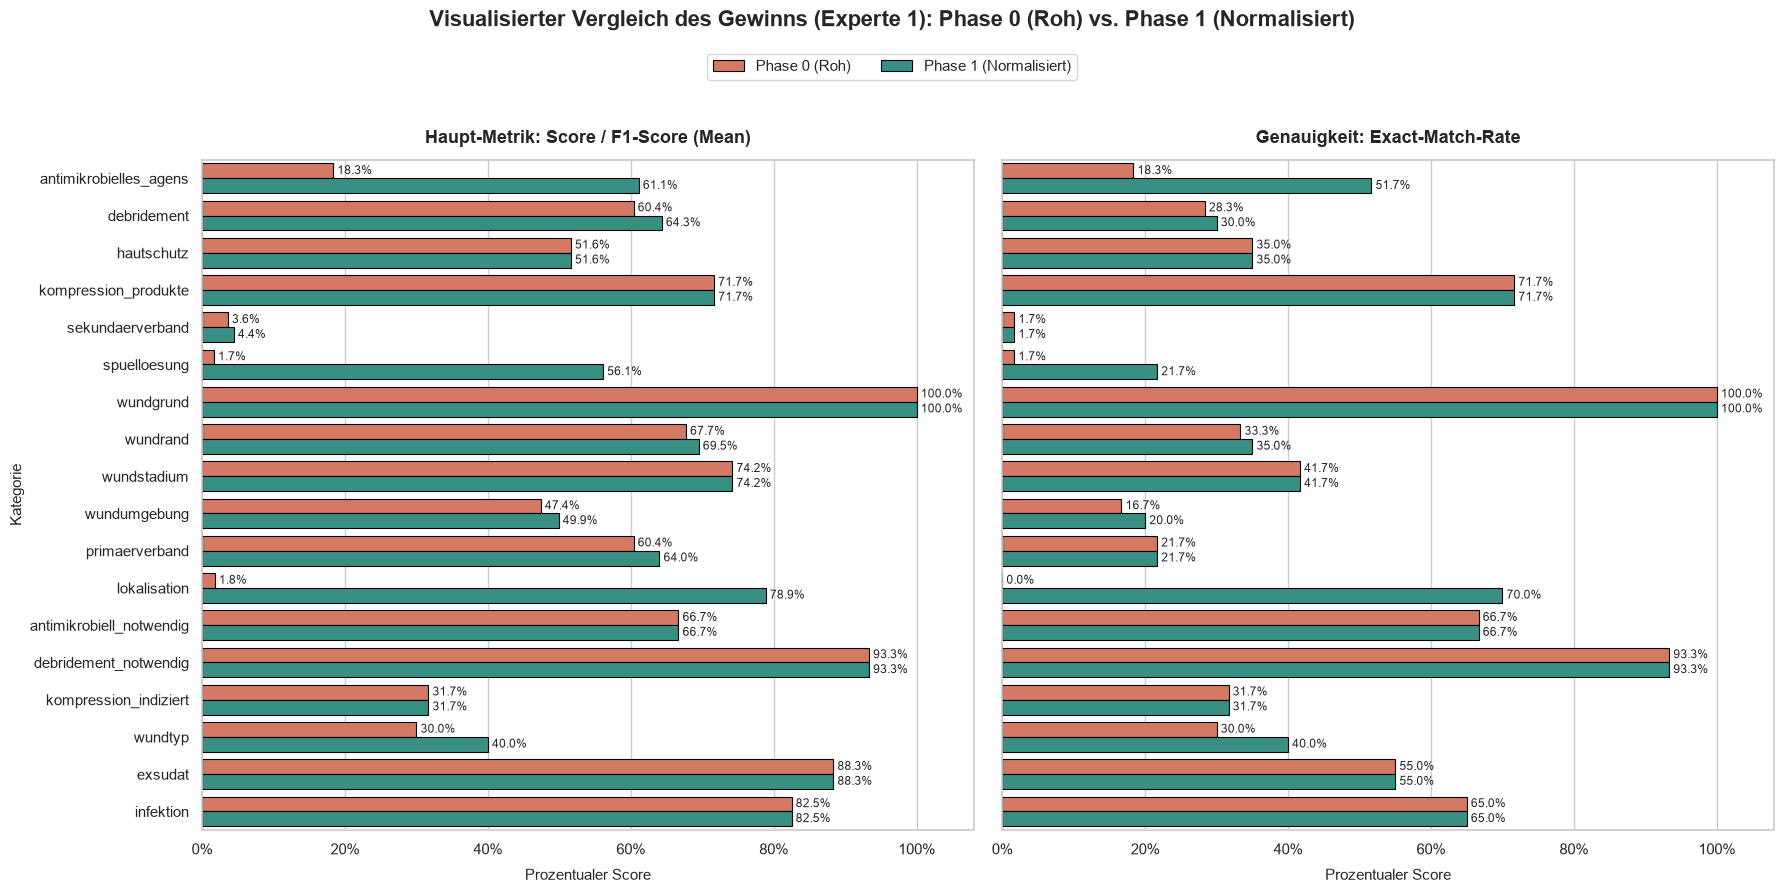

In [9]:
# Vergleicht grafisch Phase 0 und Phase 1 nebeneinander
plot_gt_comparison(df_summary_raw, df_summary_norm)


In [10]:
import importlib
import utils_notebook.compare
importlib.reload(utils_notebook.compare)

from utils_notebook.compare import compare_categories_detailed_interactive

compare_categories_detailed_interactive(
    raw_csv_gt="../data/ground_truth/allgemeine_verbandsklassen.csv",
    raw_csv_llm="../data/llm_outputs/zero_shot/zero_shot_raw/zero_shot_raw.csv",
    norm_csv_gt="../data/ground_truth/allgemeine_verbandsklassen_normalised.csv",
    norm_csv_llm="../data/llm_outputs/zero_shot/zero_shot_normalised/zero_shot_normalised.csv"
)

HTML(value="<h3 style='font-family: Segoe UI, Arial, sans-serif; color: #1d3557; margin-top: 15px;'>GT vs. LLM…

Dropdown(description='Kategorie:', index=15, layout=Layout(width='300px'), options=('Primärverband (Präferenz …

Output()